# Problema 3 - Classificação Binária: Triagem de Ambientes de Alta Salinidade
O objetivo é identificar se um local precisa ou não medidas de proteção anticorrosiva. A norma ISO 9223 define que ambientes com deposição de cloreto superior a **60 mg/m2/ano** (classes S2, S3 e S4) são considerados de **alta salinidade**, exigindo metais e revestimentos especiais ou manutenção preventiva mais frequente.

Neste notebook, reformulamos o problema de deposição de cloreto como uma tarefa de **classificação binária de triagem de risco**:
- **0**: cl <= 60 mg/m2/ano, ambiente de baixa/média salinidade e sem risco especial
- **1**: cl > 60 mg/m2/ano, ambiente de alta salinidade e precisa de proteção especial

### Diferença da Regressão
Enquanto a regressão estima o valor de cloreto, a classificação binária responde a uma pergunta de decisão: *este local precisa de proteção especial ou não?* 

### Conjunto de Dados
Mesmo dataset de cloreto (dataset_cl.xlsx), com a variável alvo binarizado=a: cl > 60 -> classe 1, se não, 0.

### Modelos Comparados
- **MLP (nossa biblioteca)**: Rede neural cosm saída sigmoid + cross-entropy binária 
- **MLPClassifier (sklearn)**: Rede neural da biblioteca sklearn 
- **Regressão Logística**: Modelo linear para classificação 
- **SVM**: Support Vector Machine 

In [1]:
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
import NNRaw.neural_network as NN

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carregamento do dataset

In [2]:
df = pd.read_excel('../datasets/dataset_cl.xlsx')

# Binarização da variável alvo: alta salinidade se cl > 60
LIMIAR = 60
df['alta_salinidade'] = (df['cl'] > LIMIAR).astype(int)

print(f'Shape: {df.shape}')
print('\nDistribuição das classes binárias:')
print(df['alta_salinidade'].value_counts())
print(f'\nProporção classe 1 (alta salinidade): {df["alta_salinidade"].mean():.1%}')

Shape: (430, 11)

Distribuição das classes binárias:
alta_salinidade
0    352
1     78
Name: count, dtype: int64

Proporção classe 1 (alta salinidade): 18.1%


In [4]:
X_cols = [
    'distance_to_coast',
    'elevation',
    'merra2_sssmass',
    'era5_wind_speed',
    'era5_time_of_wind',
    'roughness_mean'
]

## 3. Pré-processamento

O split treino/teste segue a mesma estratégia por projeto usada no notebook de regressão.

In [6]:
train_projects = [
    'international_micat_1998',
    'international_isocorrag_2010',
    'chile_vera_2012',
    'spain_canary_isles_2019',
    'international_cole_2003',
    'brazil_nutec_2008',
    'brazil_sica_2006',
    'brazil_portella_2011',
    'brazil_vitali_2013',
    'brazil_brambilla_2011',
    'brazil_pontes_2011'
]
test_projects = [
    'brazil_portella_2012',
    'brazil_vitali_2013',
    'brazil_brambilla_2011',
    'brazil_pontes_2011'
]

df_train = df[df['project_name'].isin(train_projects)].copy()
df_test  = df[df['project_name'].isin(test_projects)].copy()

print(f'Treino: {len(df_train)} e Teste: {len(df_test)}')
print(f'Proporção classe 1 no treino: {df_train["alta_salinidade"].mean():.1%}')
print(f'Proporção classe 1 no teste:  {df_test["alta_salinidade"].mean():.1%}')

Treino: 423 e Teste: 30
Proporção classe 1 no treino: 18.0%
Proporção classe 1 no teste:  33.3%


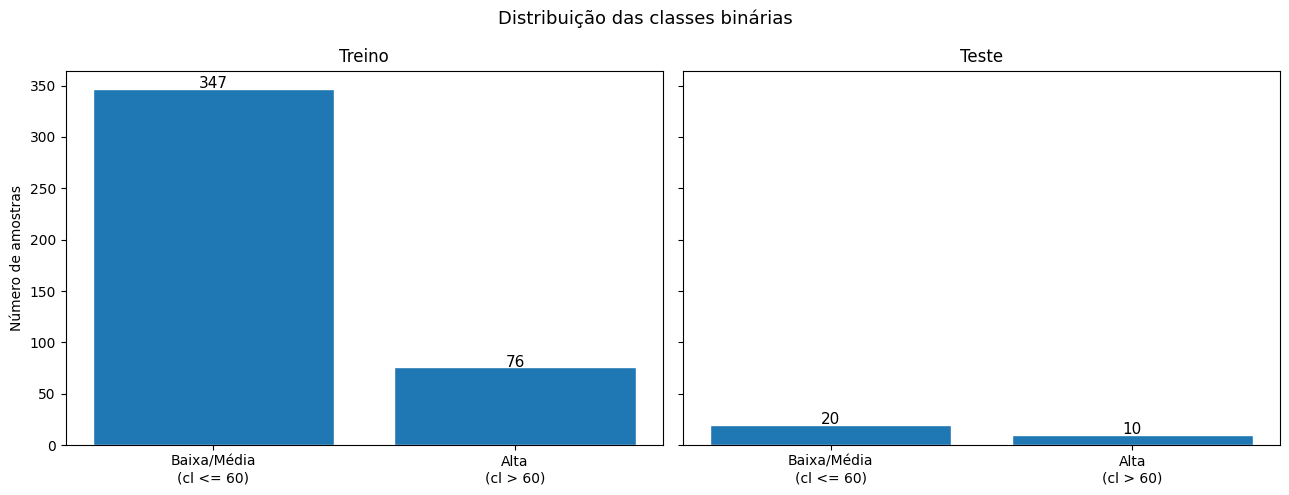

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

rotulos = ['Baixa/Média\n(cl <= 60)','Alta\n(cl > 60)'
]

# Distribuição de dados 0 ou 1 nos dados de treino
contagem_train = (
    df_train['alta_salinidade']
    .value_counts()
    .sort_index()
)

axes[0].bar(rotulos,contagem_train.values,edgecolor='white')
axes[0].set_title('Treino')
axes[0].set_ylabel('Número de amostras')

for i, v in enumerate(contagem_train.values):
    axes[0].text(i, v + 0.5,str(v),ha='center',fontsize=11)

# Distribuição de dados 0 ou 1 nos dados de teste
contagem_test = (
    df_test['alta_salinidade']
    .value_counts()
    .sort_index()
)

axes[1].bar(rotulos,contagem_test.values,edgecolor='white')
axes[1].set_title('Teste')

for i, v in enumerate(contagem_test.values):
    axes[1].text(i, v + 0.5,str(v),ha='center',fontsize=11)

plt.suptitle('Distribuição das classes binárias',fontsize=13)

plt.tight_layout()
plt.show()

In [7]:
scaler = MinMaxScaler()

X_train_raw = df_train[X_cols].to_numpy()
y_train      = df_train['alta_salinidade'].to_numpy()
X_test_raw  = df_test[X_cols].to_numpy()
y_test       = df_test['alta_salinidade'].to_numpy()

X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

# Para a nossa MLP: y como coluna (n, 1)
y_train_mlp = y_train.reshape(-1, 1).astype(float)

stratify_train = df_train['alta_salinidade']

print('Pré-processamento concluído')

Pré-processamento concluído


## 4. Cross Validation e avaliação dos modelos (Sklearn e MLP implementada) 
Usamos **Random Subsampling Estratificado** (Monte Carlo CV): 100 splits de 70%/30% mantendo a proporção das classes. As métricas são a média dos 100 splits.

In [170]:
cv = StratifiedShuffleSplit(n_splits=100, train_size=0.7, random_state=RANDOM_STATE)

def evaluate_binary(model, X, y, stratify):
    acc_list, f1_list, auc_list = [], [], []

    X_df = pd.DataFrame(X)
    y_s  = pd.Series(y)
    strat_s = pd.Series(stratify.values)

    for tr_idx, val_idx in cv.split(X_df, strat_s):
        X_tr, X_val = X_df.iloc[tr_idx].values, X_df.iloc[val_idx].values
        y_tr, y_val = y_s.iloc[tr_idx].values, y_s.iloc[val_idx].values

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        acc_list.append(accuracy_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred, zero_division=0))

        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_val)[:, 1]
        elif hasattr(model, 'decision_function'):
            proba = model.decision_function(X_val)
        else:
            proba = y_pred
        auc_list.append(roc_auc_score(y_val, proba))

    return {
        'Acurácia': np.mean(acc_list),
        'F1': np.mean(f1_list),
        'AUC-ROC': np.mean(auc_list)
    }

def evaluate_mlp_binary(X, y, stratify):

    acc_list = []
    f1_list = []
    auc_list = []

    X_df = pd.DataFrame(X)
    y_df = pd.DataFrame(y)
    strat_s = pd.Series(stratify.values)

    for tr_idx, val_idx in cv.split(X_df, strat_s):

        X_tr = X_df.iloc[tr_idx].values
        X_val = X_df.iloc[val_idx].values

        y_tr = y_df.iloc[tr_idx].values
        y_val = y_df.iloc[val_idx].values

        scaler = MinMaxScaler()

        X_tr_sc = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)

        rede = NN.RedeNeural(perda='cross_entropy_binaria')

        rede.adicionar_camada(6,16,'relu','he')
        rede.adicionar_camada(16,8,'relu','he')
        rede.adicionar_camada(8,1,'sigmoid','xavier')

        rede.treinar(
            X_tr_sc,
            y_tr,
            epocas=1000,
            taxa_aprendizado=0.1,
            tamanho_batch=32,
            verbose=False
        )

        probs = rede.prever(X_val_sc).ravel()
        y_pred = (probs >= 0.5).astype(int)

        acc_list.append(accuracy_score(y_val.ravel(), y_pred))
        f1_list.append(f1_score(y_val.ravel(),y_pred,zero_division=0))
        auc_list.append(roc_auc_score(y_val.ravel(),probs))

    return {
        "Acurácia": np.mean(acc_list),
        "F1": np.mean(f1_list),
        "AUC-ROC": np.mean(auc_list)
}

In [171]:
logit = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

svm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

mlp_sk = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

sklearn_models = {
    'Regressão Logística': logit,
    'SVM (RBF)': svm,
    'MLPClassifier (sklearn)': mlp_sk
}

In [172]:
resultados_cv = {}
tempos_treino = {}

for nome, modelo in sklearn_models.items():
    print(f'\n Avaliando {nome}')

    t0 = time.time()

    resultados_cv[nome] = evaluate_binary(
        modelo,
        X_train_raw,
        y_train,
        stratify_train
    )
    tempos_treino[nome] = time.time()-t0

    print(f'Acurácia: {resultados_cv[nome]["Acurácia"]:.4f}')
    print(f'F1: {resultados_cv[nome]["F1"]:.4f}')
    print(f'AUC: {resultados_cv[nome]["AUC-ROC"]:.4f}')
    print(f'Tempo: {tempos_treino[nome]:.2f}s')

print("\n Avaliando MLP (nossa biblioteca)")
t0 = time.time()

resultados_cv["MLP (nossa biblioteca)"] = evaluate_mlp_binary(
    X_train_raw,
    y_train_mlp,
    stratify_train
)

tempos_treino["MLP (nossa biblioteca)"] = time.time()-t0

print(f'Acurácia: {resultados_cv["MLP (nossa biblioteca)"]["Acurácia"]:.4f}')
print(f'F1: {resultados_cv["MLP (nossa biblioteca)"]["F1"]:.4f}')
print(f'AUC: {resultados_cv["MLP (nossa biblioteca)"]["AUC-ROC"]:.4f}')
print(f'Tempo: {tempos_treino["MLP (nossa biblioteca)"]:.2f}s')


 Avaliando Regressão Logística
Acurácia: 0.8211
F1: 0.0760
AUC: 0.8057
Tempo: 1.84s

 Avaliando SVM (RBF)
Acurácia: 0.8415
F1: 0.2378
AUC: 0.8480
Tempo: 2.91s

 Avaliando MLPClassifier (sklearn)
Acurácia: 0.8511
F1: 0.3820
AUC: 0.8483
Tempo: 98.76s

 Avaliando MLP (nossa biblioteca)
Acurácia: 0.8461
F1: 0.5026
AUC: 0.8962
Tempo: 234.41s


## 5. Treinamento final dos modelos com todos os dados de treino

In [181]:
logit.fit(X_train_raw, y_train)
svm.fit(X_train_raw, y_train)
mlp_sk.fit(X_train_raw, y_train)

rede = NN.RedeNeural(perda='cross_entropy_binaria')

rede.adicionar_camada(6,16,'relu','he')
rede.adicionar_camada(16,8,'relu','he')
rede.adicionar_camada(8,1,'sigmoid','xavier')

t0 = time.time()

rede.treinar(
    X_train_sc,
    y_train_mlp,
    epocas=1000,
    taxa_aprendizado=0.005,
    tamanho_batch=32,
    verbose=True)

tempo_final = time.time()-t0

Época     1/1000 | Perda treino: 0.605474
Época   100/1000 | Perda treino: 0.445607
Época   200/1000 | Perda treino: 0.410337
Época   300/1000 | Perda treino: 0.393693
Época   400/1000 | Perda treino: 0.377461
Época   500/1000 | Perda treino: 0.380395
Época   600/1000 | Perda treino: 0.356428
Época   700/1000 | Perda treino: 0.381233
Época   800/1000 | Perda treino: 0.349174
Época   900/1000 | Perda treino: 0.358042
Época  1000/1000 | Perda treino: 0.352837


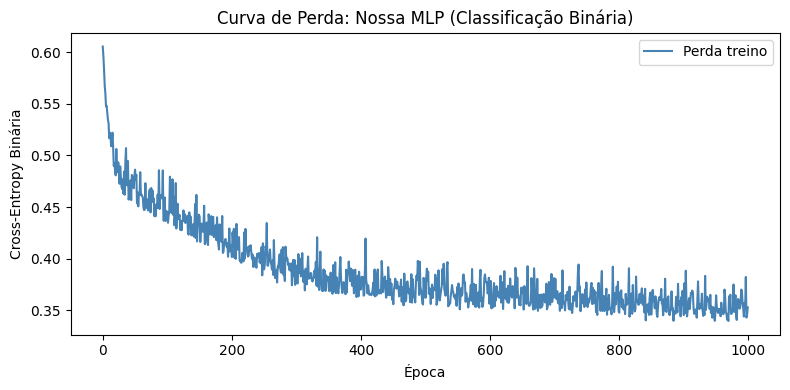

In [182]:
plt.figure(figsize=(8, 4))
plt.plot(rede.historico['perda_treino'], label='Perda treino', color='steelblue')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Binária')
plt.title('Curva de Perda: Nossa MLP (Classificação Binária)')
plt.legend()
plt.tight_layout()
plt.show()

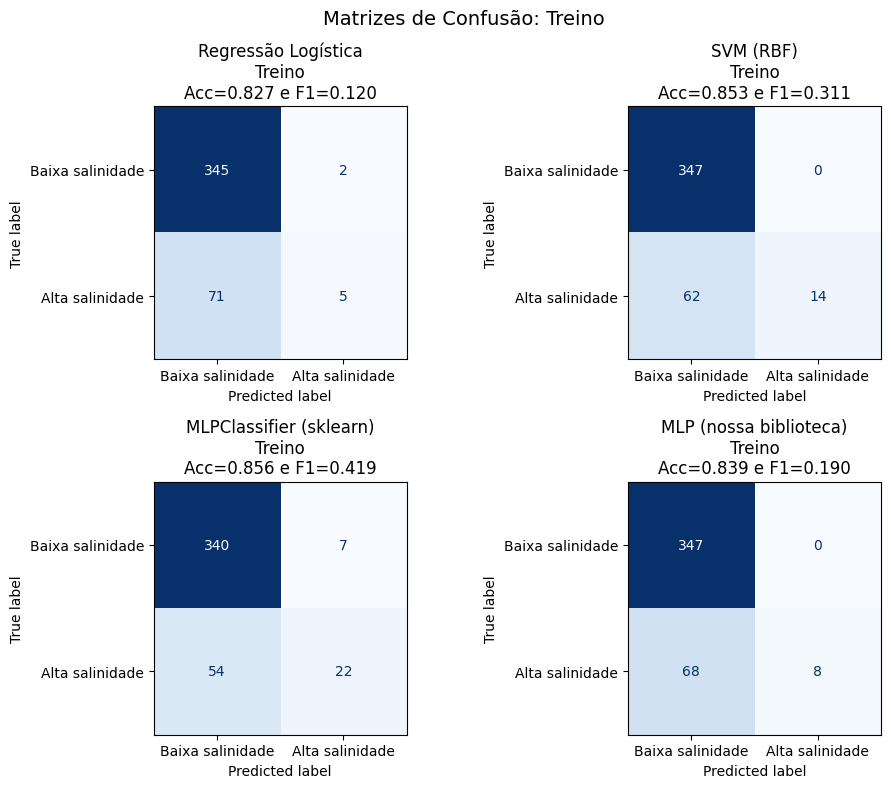

In [ ]:
# Predições no conjunto de treino
preds_train = {
    'Regressão Logística': logit.predict(X_train_raw),
    'SVM (RBF)': svm.predict(X_train_raw),
    'MLPClassifier (sklearn)': mlp_sk.predict(X_train_raw),
    'MLP (nossa biblioteca)': (
        rede.prever(X_train_sc).ravel() >= 0.5
    ).astype(int)
}

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.ravel()

for ax, (nome, y_pred) in zip(axes, preds_train.items()):
    cm = confusion_matrix(y_train, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            'Baixa salinidade',
            'Alta salinidade'
        ]
    )

    disp.plot(ax=ax,colorbar=False,cmap='Blues')
    acc = accuracy_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred,zero_division=0)
    ax.set_title(f'{nome}\nTreino\n'f'Acc={acc:.3f} e F1={f1:.3f}')

plt.suptitle('Matrizes de Confusão: Treino',fontsize=14)
plt.tight_layout()
plt.show()

## 6. Predição no conjunto de teste

In [191]:
probs_mlp = rede.prever(X_test_sc).ravel()
preds_bin = {
    "Regressão Logística":logit.predict(X_test_raw),
    "SVM (RBF)":svm.predict(X_test_raw),
    "MLPClassifier (sklearn)":mlp_sk.predict(X_test_raw),
    "MLP (nossa biblioteca)":(probs_mlp>=0.5).astype(int)
}

In [192]:
resultados_teste = {}

for nome, pred in preds_bin.items():
    if nome == "MLP (nossa biblioteca)":
        probs = probs_mlp
    elif nome == "Regressão Logística":
        probs = logit.predict_proba(X_test_raw)[:,1]
    elif nome == "MLPClassifier (sklearn)":
        probs = mlp_sk.predict_proba(X_test_raw)[:,1]
    else:
        probs = svm.predict_proba(X_test_raw)[:,1]

    resultados_teste[nome] = {
        "Acurácia":accuracy_score(y_test,pred),
        "F1":f1_score(y_test,pred,zero_division=0),
        "AUC-ROC":roc_auc_score(y_test,probs)}

In [193]:
df_teste = pd.DataFrame(resultados_teste).T.round(4)
print("\n Resultados no conjunto de teste")
display(df_teste.sort_values("AUC-ROC",ascending=False))


 Resultados no conjunto de teste


,Acurácia,F1,AUC-ROC
SVM (RBF),0.6667,0.0,0.88
Regressão Logística,0.6667,0.0,0.86
MLPClassifier (sklearn),0.6667,0.0,0.84
MLP (nossa biblioteca),0.6667,0.0,0.83


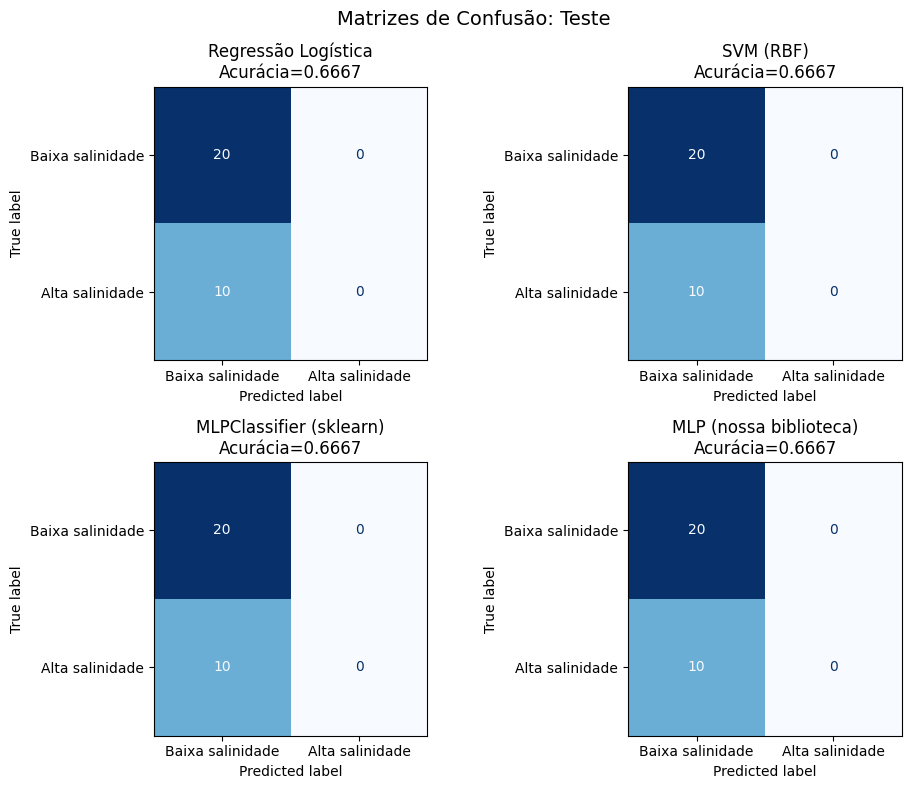

In [196]:
fig, axes = plt.subplots(2,2,figsize=(10,8))
axes = axes.ravel()

for ax, (nome, pred) in zip(axes, preds_bin.items()):
    cm = confusion_matrix(y_test,pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Baixa salinidade",
            "Alta salinidade"
        ]
)

    disp.plot(ax=ax,colorbar=False,cmap="Blues")
    acc = accuracy_score(y_test,pred)
    ax.set_title(f"{nome}\nAcurácia={acc:.4f}")

plt.suptitle('Matrizes de Confusão: Teste',fontsize=14)
plt.tight_layout()
plt.show()